In [1]:
# Copyright 2026 Google LLC
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#      https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Dashboard V2 — BigFrames Companion

<table align="left">

  <td>
    <a href="https://colab.research.google.com/github/haiyuan-eng-google/BigQuery-Agent-Analytics-SDK/blob/main/examples/dashboard_v2_bigframes.ipynb">
      <img src="https://raw.githubusercontent.com/googleapis/python-bigquery-dataframes/refs/heads/main/third_party/logo/colab-logo.png" alt="Colab logo"> Run in Colab
    </a>
  </td>
  <td>
    <a href="https://github.com/haiyuan-eng-google/BigQuery-Agent-Analytics-SDK/blob/main/examples/dashboard_v2_bigframes.ipynb">
      <img src="https://cloud.google.com/ml-engine/images/github-logo-32px.png" alt="GitHub logo"> View on GitHub
    </a>
  </td>
  <td>
    <a href="https://console.cloud.google.com/vertex-ai/workbench/deploy-notebook?download_url=https://raw.githubusercontent.com/haiyuan-eng-google/BigQuery-Agent-Analytics-SDK/main/examples/dashboard_v2_bigframes.ipynb">
      <img src="https://lh3.googleusercontent.com/UiNooY4LUgW_oTvpsNhPpQzsstV5W8F7rYgxgGBD85cWJoLmrOzhVs_ksez_HgKlFSz3Iq-WkBjgcm0hR0CDKoENQ=e14-rj-sc0xffffff-h130" alt="Vertex AI logo" width="32px"> Open in Vertex AI Workbench
    </a>
  </td>
  <td>
    <a href="https://console.cloud.google.com/bigquery">
      <img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQq0MF-jjYwlnEaAQchRjsi41Xm9IXkmIl7GA&s" alt="BQ Studio logo" width="32px"> Open in BQ Studio
    </a>
  </td>
</table>

## Overview

This is a **DataFrame-native companion** to `dashboard_v2.ipynb`. It provides
the same analytics using [BigFrames](https://cloud.google.com/bigquery/docs/bigframes-intro)
(`bigframes.pandas`) instead of raw SQL temp tables.

**Key design rule**: This notebook does NOT reimplement Dashboard V2 semantics.
It loads base DataFrames via `bpd.read_gbq(<SQL>)` using the *same SQL*
from Dashboard V2 Layer 1 — preserving the source-of-truth hierarchy:
1. ADK plugin schema
2. SDK semantic mirrors (`views.py`, `event_semantics.py`)
3. SDK aggregation patterns (`evaluators.py`)

For the canonical pure-SQL reference, see `dashboard_v2.ipynb`.

## Layer A: Setup & Configuration

In [2]:
import subprocess, sys

rc = subprocess.call(
    [sys.executable, "-m", "pip", "install", "-q",
     "--break-system-packages",
     "google-cloud-bigquery", "bigframes", "matplotlib", "pandas", "db-dtypes"],
    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
)
print("Dependencies installed." if rc == 0 else "pip install failed — check manually.")

Dependencies installed.


In [3]:
import os
import warnings

import bigframes.pandas as bpd
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore", category=UserWarning, module="bigframes")
matplotlib.rcParams["figure.dpi"] = 100

# ---------- Configuration ----------
PROJECT_ID = os.environ.get("GOOGLE_CLOUD_PROJECT", "test-project-0728-467323")
DATASET_ID = os.environ.get("BQ_DATASET", "agent_analytics")
TABLE_ID   = os.environ.get("BQ_TABLE", "agent_events")
LOCATION   = os.environ.get("BQ_LOCATION") or None
TABLE_REF  = f"`{PROJECT_ID}.{DATASET_ID}.{TABLE_ID}`"

TIME_RANGE_HOURS = 720  # last 30 days

bpd.options.bigquery.project = PROJECT_ID
if LOCATION:
    bpd.options.bigquery.location = LOCATION

def read_sql(sql):
    """Load SQL results as a pandas DataFrame via BigFrames."""
    return bpd.read_gbq(sql).to_pandas()

print(f"Project  : {PROJECT_ID}")
print(f"Location : {LOCATION or '(auto)'}")
print(f"Dataset  : {DATASET_ID}")
print(f"Table    : {TABLE_ID}")

Project  : test-project-0728-467323
Location : (auto)
Dataset  : agent_analytics
Table    : agent_events


## Layer B: Semantic Base DataFrames

Each DataFrame mirrors a Layer 1 temp table from `dashboard_v2.ipynb`,
using the **exact same SQL** for semantic extraction.

In [4]:
# filtered_events — mirrors dashboard_v2.ipynb Layer 1 cell 2
# Source-of-truth: event_semantics.py:128,136-159 + plugin schema

_WHERE = f"timestamp >= TIMESTAMP_SUB(CURRENT_TIMESTAMP(), INTERVAL {TIME_RANGE_HOURS} HOUR)"

filtered_events_df = read_sql(f"""
SELECT
  timestamp,
  event_type,
  agent,
  session_id,
  invocation_id,
  user_id,
  trace_id,
  span_id,
  parent_span_id,
  status,
  error_message,
  is_truncated,
  CASE
    WHEN event_type = 'USER_MESSAGE_RECEIVED' THEN 'user'
    WHEN event_type IN ('INVOCATION_STARTING','INVOCATION_COMPLETED') THEN 'invocation'
    WHEN event_type IN ('AGENT_STARTING','AGENT_COMPLETED') THEN 'agent'
    WHEN event_type IN ('LLM_REQUEST','LLM_RESPONSE','LLM_ERROR') THEN 'llm'
    WHEN event_type IN ('TOOL_STARTING','TOOL_COMPLETED','TOOL_ERROR') THEN 'tool'
    WHEN event_type = 'STATE_DELTA' THEN 'state'
    WHEN event_type LIKE 'HITL_%' THEN 'hitl'
    ELSE 'other'
  END AS event_family,
  (ENDS_WITH(event_type, '_ERROR')
   OR error_message IS NOT NULL
   OR status = 'ERROR') AS is_error,
  JSON_QUERY(attributes, '$.labels') AS labels,
  JSON_QUERY(attributes, '$.session_metadata') AS session_metadata,
  content,
  attributes,
  latency_ms,
  content_parts
FROM {TABLE_REF}
WHERE {_WHERE}
""")

print(f"filtered_events: {len(filtered_events_df):,} rows")
print(f"Event families : {dict(filtered_events_df['event_family'].value_counts())}")

filtered_events: 148 rows
Event families : {'tool': 50, 'llm': 48, 'agent': 20, 'invocation': 20, 'user': 10}


In [5]:
# llm_events — mirrors dashboard_v2.ipynb Layer 1 cell 3
# Source-of-truth: views.py:78-98, evaluators.py:682-712

llm_events_df = read_sql(f"""
SELECT
  timestamp, agent, session_id, invocation_id, user_id,
  trace_id, span_id, parent_span_id,
  event_type, status, error_message,
  (ENDS_WITH(event_type, '_ERROR') OR error_message IS NOT NULL OR status = 'ERROR') AS is_error,
  JSON_VALUE(attributes, '$.model') AS model,
  CAST(JSON_VALUE(content, '$.usage.prompt') AS INT64) AS usage_prompt_tokens,
  CAST(JSON_VALUE(content, '$.usage.completion') AS INT64) AS usage_completion_tokens,
  CAST(JSON_VALUE(content, '$.usage.total') AS INT64) AS usage_total_tokens,
  JSON_VALUE(attributes, '$.model_version') AS model_version,
  CAST(JSON_VALUE(latency_ms, '$.total_ms') AS FLOAT64) AS total_ms,
  CAST(JSON_VALUE(latency_ms, '$.time_to_first_token_ms') AS FLOAT64) AS ttft_ms,
  COALESCE(
    CAST(JSON_VALUE(attributes, '$.usage_metadata.prompt_token_count') AS INT64),
    CAST(JSON_VALUE(content, '$.usage.prompt') AS INT64),
    CAST(JSON_VALUE(attributes, '$.input_tokens') AS INT64)
  ) AS prompt_tokens,
  COALESCE(
    CAST(JSON_VALUE(attributes, '$.usage_metadata.candidates_token_count') AS INT64),
    CAST(JSON_VALUE(content, '$.usage.completion') AS INT64),
    CAST(JSON_VALUE(attributes, '$.output_tokens') AS INT64)
  ) AS completion_tokens,
  COALESCE(
    CAST(JSON_VALUE(attributes, '$.usage_metadata.total_token_count') AS INT64),
    CAST(JSON_VALUE(content, '$.usage.total') AS INT64),
    COALESCE(
      CAST(JSON_VALUE(attributes, '$.input_tokens') AS INT64), 0
    ) + COALESCE(
      CAST(JSON_VALUE(attributes, '$.output_tokens') AS INT64), 0
    )
  ) AS total_tokens
FROM {TABLE_REF}
WHERE {_WHERE}
  AND event_type IN ('LLM_REQUEST','LLM_RESPONSE','LLM_ERROR')
""")

print(f"llm_events: {len(llm_events_df):,} rows ({(llm_events_df['event_type'] == 'LLM_RESPONSE').sum():,} responses)")

llm_events: 48 rows (24 responses)


In [6]:
# session_rollups — mirrors dashboard_v2.ipynb Layer 1 cell 5
# Source-of-truth: evaluators.py session aggregation

session_rollups_df = read_sql(f"""
SELECT
  session_id,
  ANY_VALUE(agent) AS agent,
  ANY_VALUE(user_id) AS user_id,
  MIN(trace_id) AS first_trace_id,
  MIN(timestamp) AS start_ts,
  MAX(timestamp) AS end_ts,
  TIMESTAMP_DIFF(MAX(timestamp), MIN(timestamp), MILLISECOND) AS duration_ms,
  COUNT(*) AS total_events,
  COUNTIF(event_type = 'LLM_REQUEST') AS llm_calls,
  COUNTIF(event_type = 'TOOL_STARTING') AS tool_calls,
  COUNTIF(event_type = 'TOOL_ERROR') AS tool_errors,
  COUNTIF(event_type = 'LLM_ERROR') AS llm_errors,
  COUNTIF(event_type LIKE 'HITL_%') AS hitl_events,
  COUNTIF(event_type = 'USER_MESSAGE_RECEIVED') AS turn_count,
  COUNTIF(event_type = 'STATE_DELTA') AS state_deltas,
  COUNTIF(
    ENDS_WITH(event_type, '_ERROR')
    OR error_message IS NOT NULL
    OR status = 'ERROR'
  ) > 0 AS has_error,
  COUNT(DISTINCT invocation_id) AS invocation_count,
  COUNT(DISTINCT trace_id) AS trace_count
FROM {TABLE_REF}
WHERE {_WHERE}
GROUP BY session_id
""")

print(f"session_rollups: {len(session_rollups_df):,} sessions")
print(f"  with errors : {session_rollups_df['has_error'].sum():,}")
print(f"  total events: {session_rollups_df['total_events'].sum():,}")

session_rollups: 6 sessions
  with errors : 0
  total events: 148


In [7]:
# multimodal_parts — mirrors dashboard_v2.ipynb Layer 1 cell 7
# Source-of-truth: plugin schema content_parts UNNEST

multimodal_parts_df = read_sql(f"""
SELECT
  e.timestamp,
  e.agent,
  e.session_id,
  e.event_type,
  CASE
    WHEN e.event_type IN ('LLM_REQUEST','LLM_RESPONSE','LLM_ERROR') THEN 'llm'
    WHEN e.event_type IN ('TOOL_STARTING','TOOL_COMPLETED','TOOL_ERROR') THEN 'tool'
    ELSE 'other'
  END AS event_family,
  e.is_truncated,
  cp.mime_type,
  REGEXP_EXTRACT(cp.mime_type, r'^([^/]+)') AS mime_family,
  cp.storage_mode,
  cp.uri,
  cp.text IS NOT NULL AS has_inline_text,
  cp.part_index
FROM {TABLE_REF} e, UNNEST(e.content_parts) AS cp
WHERE {_WHERE}
  AND e.content_parts IS NOT NULL
""")

print(f"multimodal_parts: {len(multimodal_parts_df):,} parts")
if not multimodal_parts_df.empty:
    print(f"  mime families: {dict(multimodal_parts_df['mime_family'].value_counts())}")

multimodal_parts: 162 parts
  mime families: {'text': 110, 'application': 52}


## Layer C: Chart Panels

Charts built from the base DataFrames using pandas + matplotlib.
Panel structure mirrors `dashboard_v2.ipynb`.

In [8]:
# ---------- Chart helper ----------

def time_plot(df, x_col, y_cols, title, ylabel, kind="line", stacked=False, labels=None):
    """Render a time-series chart with single-point bar fallback."""
    if df.empty:
        print(f"No data for: {title}")
        return
    fig, ax = plt.subplots(figsize=(12, 4))
    if len(df) == 1:
        colors = plt.cm.tab10.colors
        x_label = str(df[x_col].iloc[0])[:16]
        if isinstance(y_cols, list):
            bar_labels = labels or y_cols
            for i, col in enumerate(y_cols):
                ax.bar(i, df[col].iloc[0], label=bar_labels[i], color=colors[i % len(colors)])
            ax.set_xticks(range(len(y_cols)))
            ax.set_xticklabels(bar_labels, rotation=45, ha="right")
        else:
            ax.bar([x_label], df[y_cols].iloc[0])
        ax.set_title(f"{title} (single time bucket: {x_label})", fontsize=12, fontweight="bold")
    else:
        if isinstance(y_cols, list):
            for i, col in enumerate(y_cols):
                lbl = labels[i] if labels else col
                if kind == "area":
                    ax.fill_between(df[x_col], df[col], alpha=0.4, label=lbl)
                    ax.plot(df[x_col], df[col], linewidth=1)
                else:
                    ax.plot(df[x_col], df[col], label=lbl, linewidth=1.5)
        else:
            if kind == "area":
                ax.fill_between(df[x_col], df[y_cols], alpha=0.4)
                ax.plot(df[x_col], df[y_cols], linewidth=1)
            else:
                ax.plot(df[x_col], df[y_cols], linewidth=1.5)
        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.tick_params(axis="x", rotation=30)
    ax.set_ylabel(ylabel)
    if isinstance(y_cols, list):
        ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### Panel 1: Token KPI

In [9]:
responses = llm_events_df[llm_events_df["event_type"] == "LLM_RESPONSE"]
total_prompt = responses["prompt_tokens"].sum()
total_completion = responses["completion_tokens"].sum()
total_all = responses["total_tokens"].sum()

print("=" * 50)
print("TOKEN KPI")
print("=" * 50)
print(f"  Prompt tokens     : {int(total_prompt):>12,}")
print(f"  Completion tokens : {int(total_completion):>12,}")
print(f"  Total tokens      : {int(total_all):>12,}")
print(f"  LLM responses     : {len(responses):>12,}")
if len(responses) > 0:
    print(f"  Avg tokens/resp   : {int(total_all / len(responses)):>12,}")

TOKEN KPI
  Prompt tokens     :       27,812
  Completion tokens :        4,048
  Total tokens      :       34,398
  LLM responses     :           24
  Avg tokens/resp   :        1,433


### Panel 2: Token Usage Over Time

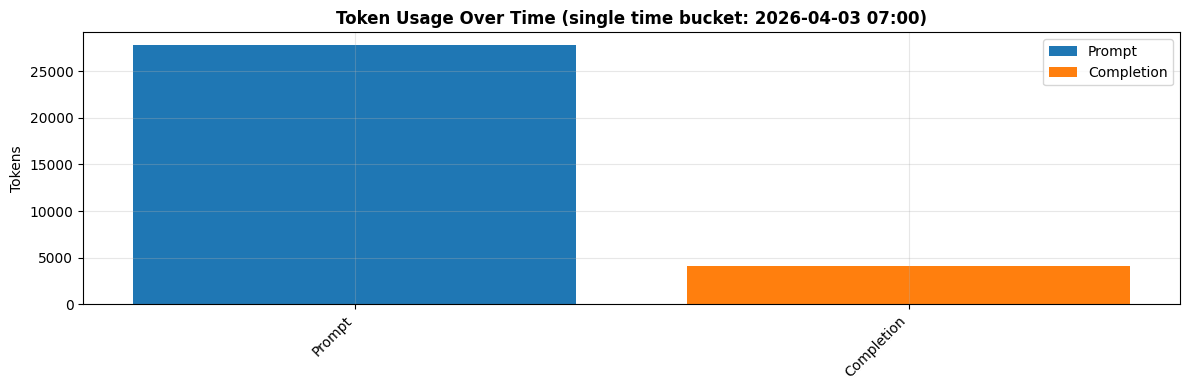

In [10]:
resp = llm_events_df[llm_events_df["event_type"] == "LLM_RESPONSE"].copy()
if not resp.empty:
    resp["hour"] = resp["timestamp"].dt.floor("h")
    hourly = resp.groupby("hour").agg(
        prompt=pd.NamedAgg(column="prompt_tokens", aggfunc="sum"),
        completion=pd.NamedAgg(column="completion_tokens", aggfunc="sum"),
        total=pd.NamedAgg(column="total_tokens", aggfunc="sum"),
    ).reset_index()
    time_plot(hourly, "hour", ["prompt", "completion"], "Token Usage Over Time", "Tokens",
              kind="area", labels=["Prompt", "Completion"])
else:
    print("No LLM response data for token chart.")

### Panel 3: Sessions Over Time

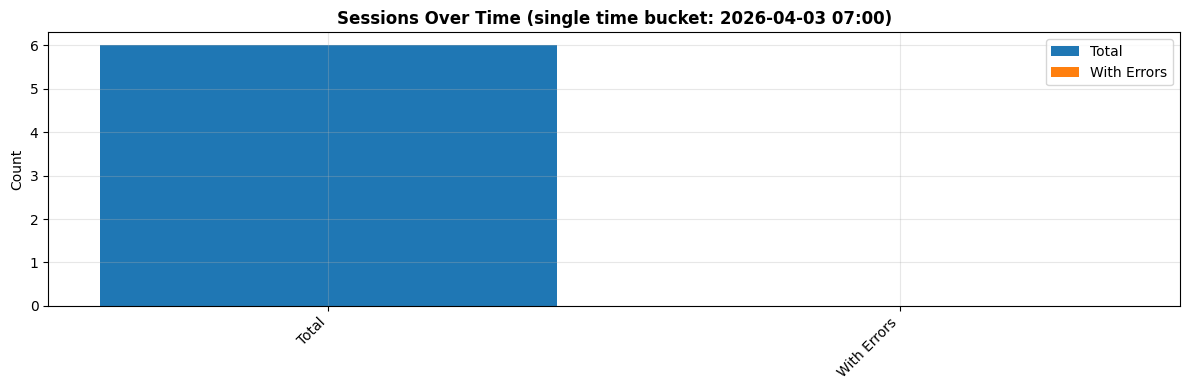

In [11]:
if not session_rollups_df.empty:
    sr = session_rollups_df.copy()
    sr["hour"] = sr["start_ts"].dt.floor("h")
    sessions_hourly = sr.groupby("hour").agg(
        sessions=pd.NamedAgg(column="session_id", aggfunc="count"),
        error_sessions=pd.NamedAgg(column="has_error", aggfunc="sum"),
    ).reset_index()
    time_plot(sessions_hourly, "hour", ["sessions", "error_sessions"],
              "Sessions Over Time", "Count", labels=["Total", "With Errors"])
else:
    print("No session data.")

### Panel 4: LLM + Tool Calls Over Time

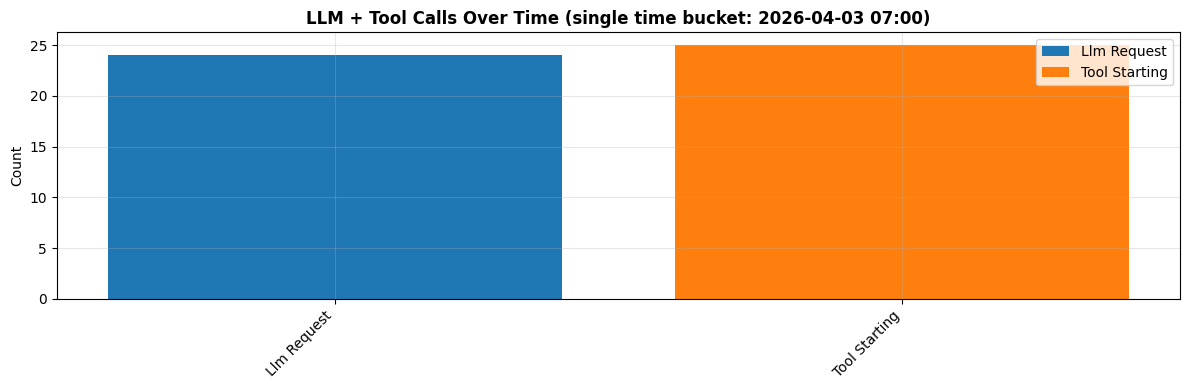

In [12]:
fe = filtered_events_df.copy()
fe["hour"] = fe["timestamp"].dt.floor("h")
calls = fe[fe["event_type"].isin(["LLM_REQUEST", "TOOL_STARTING"])].copy()
if not calls.empty:
    calls_hourly = calls.groupby(["hour", "event_type"]).size().unstack(fill_value=0).reset_index()
    cols = [c for c in ["LLM_REQUEST", "TOOL_STARTING"] if c in calls_hourly.columns]
    if cols:
        time_plot(calls_hourly, "hour", cols, "LLM + Tool Calls Over Time", "Count",
                  labels=[c.replace("_", " ").title() for c in cols])
else:
    print("No LLM/Tool call data.")

### Panel 5: Errors Over Time

In [13]:
errors = fe[fe["is_error"]].copy()
if not errors.empty:
    errors_hourly = errors.groupby(["hour", "event_family"]).size().unstack(fill_value=0).reset_index()
    err_cols = [c for c in errors_hourly.columns if c != "hour"]
    time_plot(errors_hourly, "hour", err_cols, "Errors Over Time by Family", "Count",
              labels=err_cols)
else:
    print("No errors in time range.")

No errors in time range.


### Panel 6: LLM Latency (total_ms)

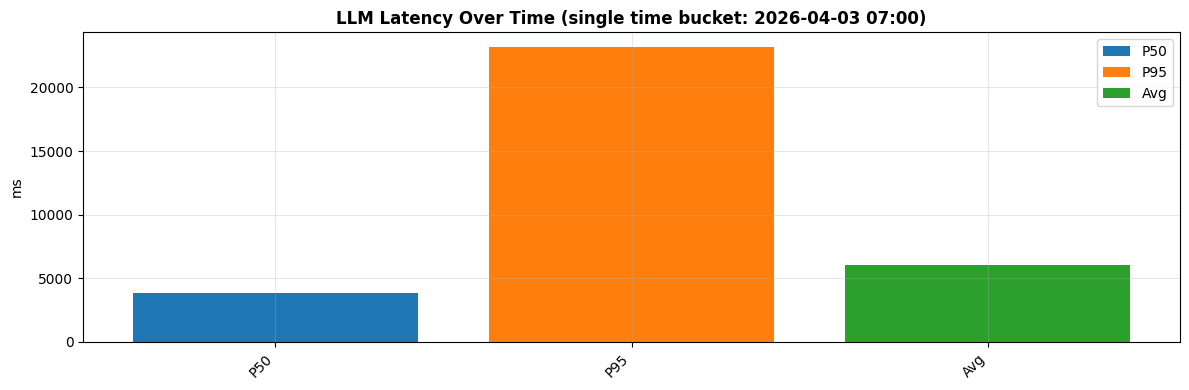

In [14]:
resp_lat = llm_events_df[
    (llm_events_df["event_type"] == "LLM_RESPONSE") & (llm_events_df["total_ms"].notna())
].copy()
if not resp_lat.empty:
    resp_lat["hour"] = resp_lat["timestamp"].dt.floor("h")
    lat_hourly = resp_lat.groupby("hour").agg(
        p50=pd.NamedAgg(column="total_ms", aggfunc="median"),
        p95=pd.NamedAgg(column="total_ms", aggfunc=lambda x: x.quantile(0.95)),
        avg=pd.NamedAgg(column="total_ms", aggfunc="mean"),
    ).reset_index()
    time_plot(lat_hourly, "hour", ["p50", "p95", "avg"],
              "LLM Latency Over Time", "ms", labels=["P50", "P95", "Avg"])
else:
    print("No LLM latency data.")

### Panel 7: TTFT (Time to First Token)

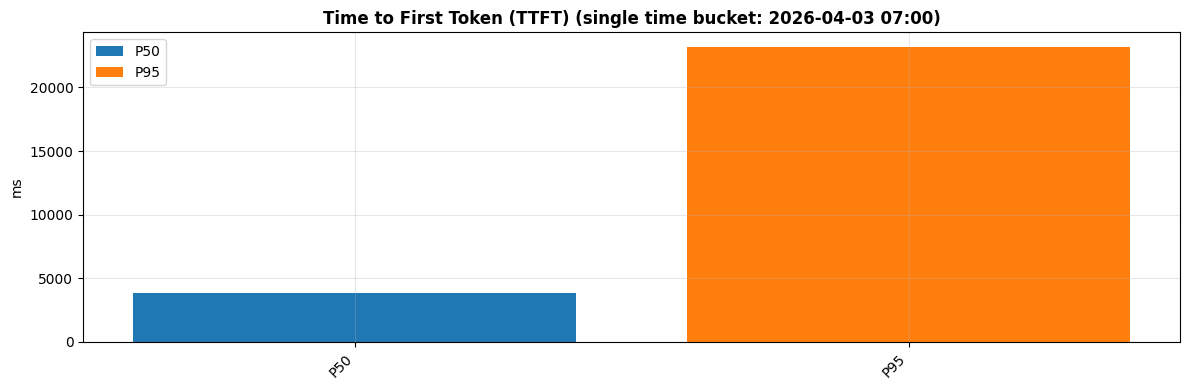

In [15]:
resp_ttft = llm_events_df[
    (llm_events_df["event_type"] == "LLM_RESPONSE") & (llm_events_df["ttft_ms"].notna())
].copy()
if not resp_ttft.empty:
    resp_ttft["hour"] = resp_ttft["timestamp"].dt.floor("h")
    ttft_hourly = resp_ttft.groupby("hour").agg(
        p50=pd.NamedAgg(column="ttft_ms", aggfunc="median"),
        p95=pd.NamedAgg(column="ttft_ms", aggfunc=lambda x: x.quantile(0.95)),
    ).reset_index()
    time_plot(ttft_hourly, "hour", ["p50", "p95"],
              "Time to First Token (TTFT)", "ms", labels=["P50", "P95"])
else:
    print("No TTFT data.")

### Panel 8: Multimodal by MIME Family

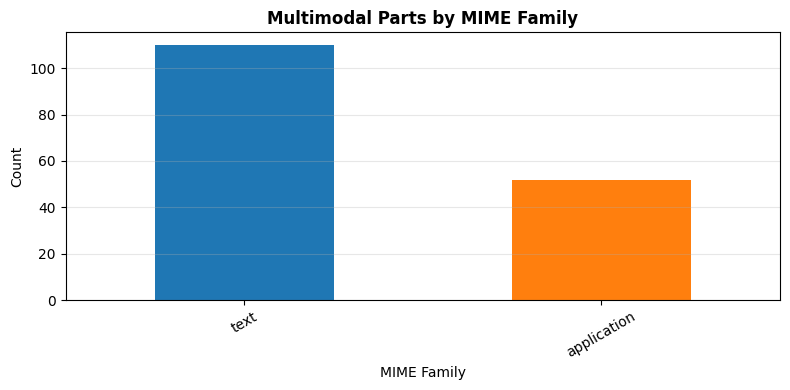

Truncation rate: 0.0% of events with content_parts


In [16]:
if not multimodal_parts_df.empty:
    mime_counts = multimodal_parts_df["mime_family"].value_counts()
    fig, ax = plt.subplots(figsize=(8, 4))
    mime_counts.plot.bar(ax=ax, color=plt.cm.tab10.colors[:len(mime_counts)])
    ax.set_title("Multimodal Parts by MIME Family", fontsize=12, fontweight="bold")
    ax.set_ylabel("Count")
    ax.set_xlabel("MIME Family")
    ax.tick_params(axis="x", rotation=30)
    ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()

    # Truncation rate
    fe_with_parts = filtered_events_df[
        filtered_events_df["content_parts"].notna()
    ]
    if not fe_with_parts.empty:
        trunc_rate = fe_with_parts["is_truncated"].mean()
        print(f"Truncation rate: {trunc_rate:.1%} of events with content_parts")
else:
    print("No multimodal parts in time range.")

### Panel 9: Recent Sessions Table

In [17]:
if not session_rollups_df.empty:
    recent = session_rollups_df.sort_values("start_ts", ascending=False).head(15)
    display_cols = [
        "session_id", "agent", "user_id", "start_ts",
        "total_events", "llm_calls", "tool_calls",
        "has_error", "duration_ms", "turn_count",
    ]
    cols = [c for c in display_cols if c in recent.columns]
    display(recent[cols].reset_index(drop=True))
else:
    print("No sessions.")

,session_id,agent,user_id,start_ts,total_events,llm_calls,tool_calls,has_error,duration_ms,turn_count
0,e2e-a9b40dfdbe84,travel_planner,demo_user,2026-04-03 07:44:09.959171+00:00,33,6,3,False,46182,3
1,e2e-054c12957ba3,travel_planner,demo_user,2026-04-03 07:43:59.632517+00:00,19,3,4,False,9920,1
2,e2e-781fb52f3814,travel_planner,demo_user,2026-04-03 07:43:46.386415+00:00,21,3,5,False,12856,1
3,e2e-3171eb36991f,travel_planner,demo_user,2026-04-03 07:37:14.206646+00:00,33,6,3,False,26136,3
4,e2e-f676e06a719e,travel_planner,demo_user,2026-04-03 07:36:54.241866+00:00,19,3,4,False,19455,1
5,e2e-125750c7b94d,travel_planner,demo_user,2026-04-03 07:36:20.755950+00:00,23,3,6,False,33078,1


## Layer D: Span-Tree Drill-Down

Reconstructs the span hierarchy for the most recent session.

In [18]:
target_session = None
if not session_rollups_df.empty:
    target_session = session_rollups_df.sort_values("start_ts", ascending=False)["session_id"].iloc[0]

if target_session:
    events = read_sql(f"""
    SELECT
      span_id,
      parent_span_id,
      event_type,
      CASE
        WHEN event_type IN ('LLM_REQUEST','LLM_RESPONSE','LLM_ERROR') THEN 'llm'
        WHEN event_type IN ('TOOL_STARTING','TOOL_COMPLETED','TOOL_ERROR') THEN 'tool'
        ELSE 'other'
      END AS event_family,
      agent,
      status,
      error_message,
      CAST(JSON_VALUE(latency_ms, '$.total_ms') AS FLOAT64) AS total_ms,
      CAST(JSON_VALUE(latency_ms, '$.time_to_first_token_ms') AS FLOAT64) AS ttft_ms,
      timestamp
    FROM {TABLE_REF}
    WHERE session_id = '{target_session}'
    ORDER BY timestamp
    """)

    # Aggregate events into spans (deduplicate by span_id)
    span_map = {}
    for _, row in events.iterrows():
        sid = row.get("span_id")
        if not sid or pd.isna(sid):
            continue
        if sid not in span_map:
            span_map[sid] = {
                "span_id": sid,
                "parent_span_id": row.get("parent_span_id") if pd.notna(row.get("parent_span_id")) else None,
                "agent": row.get("agent"),
                "events": [],
                "total_ms": None,
                "ttft_ms": None,
                "has_error": False,
                "error_message": None,
            }
        span_map[sid]["events"].append(row.get("event_type", ""))
        total_ms = row.get("total_ms")
        if pd.notna(total_ms) and total_ms > 0:
            span_map[sid]["total_ms"] = float(total_ms)
        ttft_ms = row.get("ttft_ms")
        if pd.notna(ttft_ms) and ttft_ms > 0:
            span_map[sid]["ttft_ms"] = float(ttft_ms)
        err_msg = row.get("error_message")
        if pd.notna(err_msg) and err_msg:
            span_map[sid]["has_error"] = True
            span_map[sid]["error_message"] = str(err_msg)
        status = row.get("status")
        if pd.notna(status) and status == "ERROR":
            span_map[sid]["has_error"] = True

    # Build tree
    children = {}
    roots = []
    for sid, span in span_map.items():
        pid = span.get("parent_span_id")
        if pid and pid in span_map:
            children.setdefault(pid, []).append(span)
        else:
            roots.append(span)

    def print_tree(node, indent=0):
        sid = node["span_id"][:8]
        evts = ", ".join(node["events"])
        ag = node.get("agent") or ""
        lat = node.get("total_ms")
        err = node.get("error_message")
        prefix = "  " * indent
        err_mark = " *** ERROR" if node["has_error"] else ""
        lat_str = f" ({lat:.0f}ms)" if lat and lat > 0 else ""
        print(f"{prefix}[{sid}] events=[{evts}] agent={ag}{lat_str}{err_mark}")
        if err:
            print(f"{prefix}  error: {str(err)[:100]}")
        for child in children.get(node["span_id"], []):
            print_tree(child, indent + 1)

    print(f"Span tree for session: {target_session}")
    print(f"Total events: {len(events)}, Unique spans: {len(span_map)}")
    print("=" * 70)
    for root in roots:
        print_tree(root)
else:
    print("No sessions available for drill-down.")

Span tree for session: e2e-a9b40dfdbe84
Total events: 33, Unique spans: 15
[1c5d2a3d] events=[USER_MESSAGE_RECEIVED, INVOCATION_STARTING, INVOCATION_COMPLETED] agent=travel_planner (4078ms)
  [4da56afc] events=[AGENT_STARTING, AGENT_COMPLETED] agent=travel_planner (4077ms)
    [ca1069a7] events=[LLM_REQUEST, LLM_RESPONSE] agent=travel_planner (2148ms)
    [0c421077] events=[TOOL_STARTING, TOOL_COMPLETED] agent=travel_planner
    [cb1f5828] events=[LLM_REQUEST, LLM_RESPONSE] agent=travel_planner (1914ms)
[6d944fa2] events=[USER_MESSAGE_RECEIVED, INVOCATION_STARTING, INVOCATION_COMPLETED] agent=travel_planner (35705ms)
  [c11e0281] events=[AGENT_STARTING, AGENT_COMPLETED] agent=travel_planner (35704ms)
    [6a6e6b52] events=[LLM_REQUEST, LLM_RESPONSE] agent=travel_planner (29060ms)
    [ba01fa7e] events=[TOOL_STARTING, TOOL_COMPLETED] agent=travel_planner
    [8a1d7785] events=[LLM_REQUEST, LLM_RESPONSE] agent=travel_planner (6631ms)
[edaac2cc] events=[USER_MESSAGE_RECEIVED, INVOCATION_S

## Parity Validation

Compare key metrics against `dashboard_v2.ipynb` on the same dataset/time window.

In [19]:
print("=" * 60)
print("PARITY VALIDATION — compare these with dashboard_v2.ipynb")
print("=" * 60)
print(f"  Filtered events     : {len(filtered_events_df):>10,}")
print(f"  Distinct sessions   : {filtered_events_df['session_id'].nunique():>10,}")
print(f"  LLM events          : {len(llm_events_df):>10,}")
resp_df = llm_events_df[llm_events_df['event_type'] == 'LLM_RESPONSE']
print(f"  Total tokens        : {int(resp_df['total_tokens'].sum()):>10,}")
print(f"  Error events        : {int(filtered_events_df['is_error'].sum()):>10,}")
print(f"  Multimodal parts    : {len(multimodal_parts_df):>10,}")
if not resp_df.empty and resp_df['ttft_ms'].notna().any():
    print(f"  TTFT median (ms)    : {resp_df['ttft_ms'].median():>10.1f}")
if target_session and 'events' in dir():
    print(f"  Drill-down events   : {len(events):>10,}")
    print(f"  Drill-down spans    : {len(span_map):>10,}")

PARITY VALIDATION — compare these with dashboard_v2.ipynb
  Filtered events     :        148
  Distinct sessions   :          6
  LLM events          :         48
  Total tokens        :     34,398
  Error events        :          0
  Multimodal parts    :        162
  TTFT median (ms)    :     3837.0
  Drill-down events   :         33
  Drill-down spans    :         15


---

**End of Dashboard V2 BigFrames Companion Notebook**